# Intelligent Agents: Reflex-Based Agents for GridHunt (Multi-agent Environment)

Student Name: [Add your name]

I have used the following AI tools: [list tools]

I understand that my submission needs to be my own work: [your initials]

## Learning Outcomes

* Apply core AI concepts by implementing the agent function for a simple and model-based reflex agents that respond to environmental percepts.
* Practice how the environment and the agent function interact.
* Analyze agent performance through controlled experiments across different environment configurations.

## Instructions

Total Points: 10

Complete this notebook. Use the provided notebook cells and insert additional code and markdown cells as needed. Submit the completely rendered notebook.
### AI Use

Here are some guidelines that will make it easier for you:

* __Don't:__ Rely on AI auto completion. You will waste a lot of time trying to figure out how the suggested code relates to what we do in class. Turn off AI code completion (e.g., Copilot) in your IDE.
* __Don't:__ Do not submit code/text that you do not understand or have not checked to make sure that it is complete and correct.
* __Do:__ Use AI for debugging and letting it explain code and concepts from class.

## Introduction

![GridHunt Image](gridhunt.png)

Gridhunt is a small educational game that helps you practice implementing simple agent functions. It is a modified Python reimplementation of Gridhunt2. 

The objective of gridhunt is to implement an intelligent agent, the hunter, who can catch a monster faster than all other hunters. Gridhunt uses a $n \times n$ arena consisting of a grid of tiles. Gridhunt is a turn-based game, and several hunter agents and the monster agent move around in the arena. A hunter catches the monster if she/he moves on the same square the monster currently occupies. The hunters compete fow who catches the monster first. If the monster survives the maximum number of steps for the game, then the monster wins.

## PEAS Description of Gridhunt

__Performance Measure:__ The performance is measured as the number of steps the hunter uses to catch the monster. Catching the monster means to be on the same square.

__Environment:__ An arena with $n \times n$ squares. At the beginning the monster and the hunters are randomly placed in the arena environment. The hunters and the monster
    can move around, but cannot leave the arena. Since there are three agents involved, this is a competitive multi-agent environment.

__Actuators:__ The agent can move to an adjacent square using actions "north", "east", "west", and "south", or teleport which will move the agent 
    to a random square in the arena.

__Sensors:__ The agent can always see its location in the arena and the location of the monster.  

## The Arena Environment

The environment manages the location of the agents (hunter and monster). It initially places them in a random location and then provides them in every step with percepts (the location of the hunter and the monster) and asks them for their action. 

__A Note on positions:__
The arena is implemented as an array with row and column indices representing the position.
Positions are stored in a numpy array where `pos[0]` is the row index and `pos[1]` is the column index in the arena. North means up in this array, that is the row index gets smaller when going north. Remember indices in Python start with 0 and go to `n-1`.

In [2]:
import numpy as np
from IPython.display import clear_output
from time import sleep

def arena_environment(hunter_1_agent_function, hunter_2_agent_function, monster_agent_function, n = 30, max_steps = 100, visualize = False, animation = False):
    """
    Simulate an arena where two hunter agent tries to catch a monster agent.

    Parameters:
    hunter_1_agent_function and hunter_2_agent_function (function): A function that takes the current positions of the hunter and monster
                                      and returns the next move for the hunter ('north', 'east', 'west', 'south', 'teleport').
    monster_agent_function (function): A function that takes the current positions of the hunter and monster
                                       and returns the next move for the monster (or 'stay' to remain in place).
    n (int): The size of the arena (n x n grid).
    max_steps (int): The maximum number of steps to simulate.
    visualize (bool): Whether to visualize the arena.
    animation (bool): Whether to animate the visualization with a delay.

    Returns:
    int: The number of steps taken for the hunter to catch the monster or np.nan (not a number) if not caught.
    """
    
    # Initialize positions
    monster_pos = np.random.randint(0, n-1, size=2)
    hunter_1_pos = np.random.randint(0, n-1, size=2)
    while np.array_equal(hunter_1_pos, monster_pos):
        hunter_1_pos = np.random.randint(0, n-1, size=2)
    hunter_2_pos = np.random.randint(0, n-1, size=2)
    while np.array_equal(hunter_2_pos, monster_pos):
        hunter_2_pos = np.random.randint(0, n-1, size=2)    
    
    def move(action, position):
        """calculate new position for the agent."""
        if action == 'north':
            position[0] -= 1
        elif action == 'south':
            position[0] += 1
        elif action == 'west':
            position[1] -= 1
        elif action == 'east':
            position[1] += 1
        else:
            raise ValueError("Invalid action.")
        
        # Ensure position stays within bounds
        position = np.clip(position, 0, n-1)
        return position

    def print_arena():

        if animation:
            sleep(1)
            clear_output(wait=True)
        print(f"Step {step}:")
        print(f"Hunter 1 is at '{hunter_1_pos}'; Hunter 2 is at '{hunter_2_pos}'; Monster is at '{monster_pos}'\n")
        arena = np.full((n, n), '.', dtype=str)
        arena[monster_pos[0], monster_pos[1]] = 'M'
        arena[hunter_1_pos[0], hunter_1_pos[1]] = '1'
        arena[hunter_2_pos[0], hunter_2_pos[1]] = '2'
        print("\n".join("".join(row) for row in arena))

    for step in range(max_steps):
        if visualize:
            print_arena()
        
        # Check if hunter has caught the monster
        if np.array_equal(hunter_1_pos, monster_pos):
            if visualize:
                print(f"Hunter 1 caught the monster in {step} steps!")
            return ("1", step)
        
        if np.array_equal(hunter_2_pos, monster_pos):
            if visualize:
                print(f"Hunter 2 caught the monster in {step} steps!")
            return ("2", step)

        # Get next move from monster agent function
        monster_action = monster_agent_function(monster_pos, hunter_1_pos, hunter_2_pos)
        if monster_action != 'stay':
            monster_pos = move(monster_action, monster_pos)

        # Get next move from hunter agent function
        hunter_1_action = hunter_1_agent_function(hunter_1_pos, monster_pos)
        if hunter_1_action == 'teleport':
            hunter_1_pos = np.random.randint(0, n-1, size=2)
        else:
            hunter_1_pos = move(hunter_1_action, hunter_1_pos)

        hunter_2_action = hunter_2_agent_function(hunter_2_pos, monster_pos)
        if hunter_2_action == 'teleport':
            hunter_2_pos = np.random.randint(0, n-1, size=2)
        else:
            hunter_2_pos = move(hunter_2_action, hunter_2_pos)
    
        # print the agents' actions
        if visualize:
            print(f"Hunter 1 chose action '{hunter_1_action}'")
            print(f"Hunter 2 chose action '{hunter_2_action}'")
            print(f"Monster chose action '{monster_action}'")
            print("\n" + "="*n + "\n")

    # the hunter failed to catch the monster within max_steps
    if visualize:
        print(f"Monster won by surviving {max_steps} steps.")
    
    return ("M", np.nan)

I implement the monster here as a simple agent that moves around randomly, but mostly stays in its place. You can use AI to get a detailed explanation of how the following code works.

In [3]:
monster_actions = ["north", "east", "west", "south", "stay"]

def monster_agent_function_simple(monster_pos, hunter_1_pos, hunter_2_pos):
    return np.random.choice(monster_actions, p=[0.125, 0.125, 0.125, 0.125, 0.5])

# The Hunter Agent

Your job is to implement a simple-reflex hunter agent that can catch the monster. Remember, your agent is implemented as an agent function that get percepts and needs to return a valid action. The actions are: 

In [4]:
actions = ["north", "east", "west", "south", "teleport"]

## A Simple Example Implementation

Here is a very simple hunter that just runs around randomly and hopes that it bumps into the monster. 

In [5]:
def simple_randomized_hunter_agent_function(hunter_location, monster_location):
    return np.random.choice(actions)

Ask the agent for an action.

In [6]:
simple_randomized_hunter_agent_function([0,0], [5,5])

np.str_('teleport')

## Experimenting With the Agent

We can place the monster and the hunter into the environment and run a simulation by calling the environment function.

In [7]:
hunter_1 = simple_randomized_hunter_agent_function
hunter_2 = simple_randomized_hunter_agent_function

arena_environment(hunter_1, 
                  hunter_2, 
                  monster_agent_function_simple, 
                  n=5, max_steps=5, visualize=True, animation=False)

Step 0:
Hunter 1 is at '[2 0]'; Hunter 2 is at '[3 1]'; Monster is at '[2 1]'

.....
.....
1M...
.2...
.....
Hunter 1 chose action 'teleport'
Hunter 2 chose action 'east'
Monster chose action 'stay'

=====

Step 1:
Hunter 1 is at '[0 3]'; Hunter 2 is at '[3 2]'; Monster is at '[2 1]'

...1.
.....
.M...
..2..
.....
Hunter 1 chose action 'east'
Hunter 2 chose action 'teleport'
Monster chose action 'south'

=====

Step 2:
Hunter 1 is at '[0 4]'; Hunter 2 is at '[2 0]'; Monster is at '[3 1]'

....1
.....
2....
.M...
.....
Hunter 1 chose action 'east'
Hunter 2 chose action 'south'
Monster chose action 'east'

=====

Step 3:
Hunter 1 is at '[0 4]'; Hunter 2 is at '[3 0]'; Monster is at '[3 2]'

....1
.....
.....
2.M..
.....
Hunter 1 chose action 'south'
Hunter 2 chose action 'east'
Monster chose action 'north'

=====

Step 4:
Hunter 1 is at '[1 4]'; Hunter 2 is at '[3 1]'; Monster is at '[2 2]'

.....
....1
..M..
.2...
.....
Hunter 1 chose action 'east'
Hunter 2 chose action 'east'
Monster c

('M', nan)

### Trực quan hóa Đồ họa Pixel-Art trên lưới 5x5 (Nguyên bản như ảnh mẫu)
Bạn có thể phát hoạt họa tương tác với giao diện Pixel Art chuẩn như ảnh đề bài:


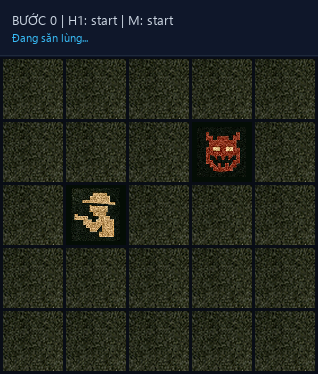
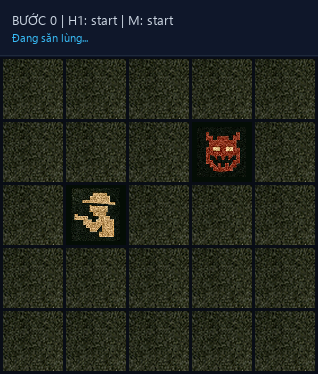
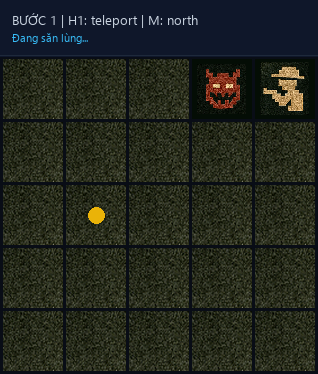
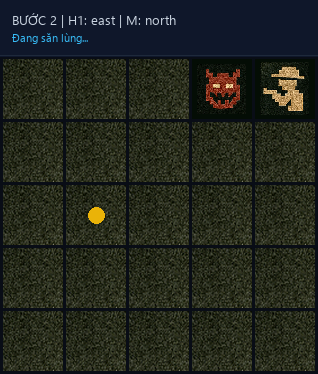
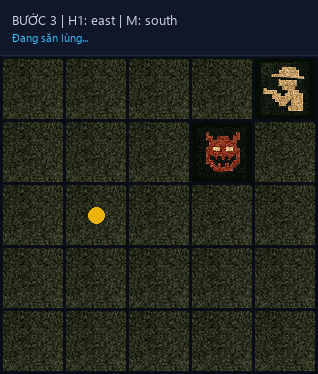
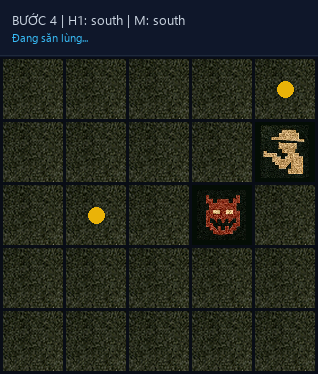
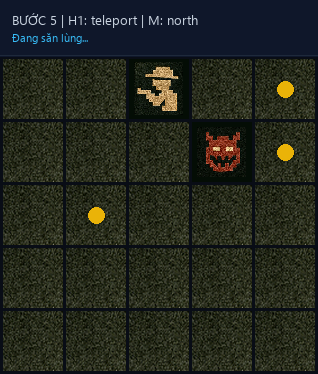
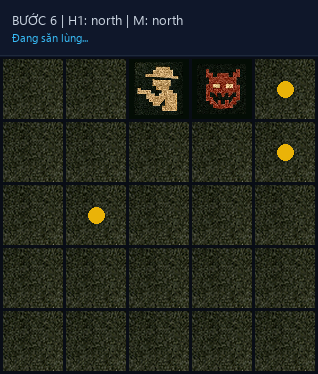
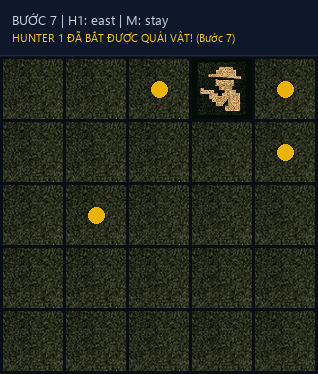

In [8]:
from gridhunt_visualizer import play_gridhunt

# Mô phỏng lưới 5x5 nguyên bản 1 Thợ săn vs 1 Quái vật:
play_gridhunt(
    hunter_1_func=simple_randomized_hunter_agent_function,
    hunter_2_func=None,
    monster_func=monster_agent_function_simple,
    n=5,
    max_steps=20
)

Well, this was one run, maybe it was just good or bad luck this time!

Let's run an experiment with 100 runs in a $20 \times 20$ arena.  

In [9]:
hunter_1 = simple_randomized_hunter_agent_function
hunter_2 = simple_randomized_hunter_agent_function

steps = [arena_environment(hunter_1, 
                           hunter_2, 
                           monster_agent_function_simple, 
                           n=20, max_steps=100, visualize=False) for _ in range(100)] 
print(steps)

[('M', nan), ('M', nan), ('M', nan), ('1', 79), ('M', nan), ('2', 70), ('M', nan), ('M', nan), ('2', 40), ('M', nan), ('1', 86), ('2', 34), ('M', nan), ('1', 27), ('M', nan), ('2', 86), ('M', nan), ('M', nan), ('1', 20), ('1', 4), ('M', nan), ('M', nan), ('1', 46), ('2', 63), ('M', nan), ('M', nan), ('M', nan), ('1', 94), ('M', nan), ('2', 66), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('2', 32), ('2', 53), ('2', 97), ('M', nan), ('2', 94), ('2', 40), ('M', nan), ('M', nan), ('M', nan), ('1', 17), ('2', 61), ('M', nan), ('2', 67), ('M', nan), ('2', 23), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('2', 96), ('M', nan), ('1', 44), ('M', nan), ('M', nan), ('M', nan), ('1', 72), ('M', nan), ('1', 49), ('M', nan), ('1', 6), ('M', nan), ('M', nan), ('1', 48), ('M', nan), ('M', nan), ('M', nan), ('1', 82), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('2', 28), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan),

We just got a list with who one and the number of steps to catch the monster for 100 simulation runs.
Let's analysis the results by counting who won how often.

In [10]:
steps = np.array(steps)

print (f"Hunter 1 won: {np.sum(steps[:,0] == '1')}")
print (f"Hunter 2 won: {np.sum(steps[:,0] == '2')}")
print (f"Monster 1 won: {np.sum(steps[:,0] == 'M')}")       


Hunter 1 won: 17
Hunter 2 won: 17
Monster 1 won: 66


The random agent in not a very good hunter. You need to implement a better agent function.

# Your Agent Implementation [4 points]

Write a new hunter agent function that chases the monster. Copy the simple randomized hunter function from above and modify it using rules based on the monster's and the hunter's location. Let your hunter compete with the random agent. You can also come up with several different agents and let them compete against each other.

In [11]:
# 1. SMART HUNTER (Graeedy Manhattan Reflex - Không Teleport)

def smart_hunter_agent_function(hunter_location, monster_location):
    """ Reflex Agent : Di chuyển theo thuật toán Manhattan, 
        ưu tiên trục có độ lêch lớn hơn để tiếp cận Monster nhanh nhất.
    """

    d_row = monster_location[0] - hunter_location[0]
    d_col = monster_location[1] - hunter_location[1]

    if d_row == 0 and d_col == 0:
        return "north"
    
    row_action = "north" if d_row < 0 else "south"
    col_action = "west" if d_col < 0 else "east"

    if d_row == 0:
        return col_action
    if d_col == 0:
        return row_action
    
    if abs(d_row) > abs(d_col):
        return row_action
    elif abs(d_row) < abs(d_col):
        return col_action
    else :
        return np.random.choice([row_action, col_action])
    

In [12]:
# 2. TELEPORT HUNTER (Được phép teleport khi khoảng cách quá xa)
def teleport_hunter_agent_function(hunter_location, monster_location):
    """ Reflex Agent có điều kiện cho Teleport:
        
        Nếu ở quá xa, có 30% xác suất cơ hội teleport để thư vận may có
        áp sát được mục tiêu hay không. Nếu ở gần thì vẫn giữ nguyên sử 
        dụng thuật toán Manhattan để tiếp cận mục tiêu.
    """

    d_row = monster_location[0] - hunter_location[0]
    d_col = monster_location[1] - hunter_location[1]
    manhattan_dist = abs(d_row) + abs(d_col)

    if manhattan_dist > 15 and np.random.rand() <= 0.3:
        return "teleport"
    
    return smart_hunter_agent_function(hunter_location, monster_location)



# Your Experiments [2 points]

Copy the simulation code from above and run experiments with your agent. 
Experiment with larger arenas of at least size $30 \times 30$.

### 1. Thực nghiệm 1: Trực quan hóa một ván đấu mẫu ($20 \times 20$)

* **Mục tiêu:** Quan sát trực quan bước đi thực tế của các tác tử trên sàn đấu $20 \times 20$ có hoạt ảnh bước đi (`animation=True`):
  * **Hunter 1:** `simple_randomized_hunter_agent_function` (chọn hành động ngẫu nhiên hoàn toàn).
  * **Hunter 2:** `smart_hunter_agent_function` (áp dụng thuật toán truy đuổi Manhattan phản xạ, ưu tiên trục có độ lệch lớn hơn).
  * **Monster:** `monster_agent_function_simple` (quái vật di chuyển ngẫu nhiên hoặc 50% đứng yên).
* **Thiết lập:** $n = 20$, `max_steps = 100`, `visualize = True`, `animation = True`.

In [13]:
hunter_1 = simple_randomized_hunter_agent_function
hunter_2 = smart_hunter_agent_function

arena_environment(hunter_1, 
                  hunter_2, 
                  monster_agent_function_simple, 
                  n=20, max_steps=100, visualize=True, animation=True)

Step 16:
Hunter 1 is at '[5 8]'; Hunter 2 is at '[14 14]'; Monster is at '[14 14]'

....................
....................
....................
....................
....................
........1...........
....................
....................
....................
....................
....................
....................
....................
....................
..............2.....
....................
....................
....................
....................
....................
Hunter 2 caught the monster in 16 steps!


('2', 16)

### 2. Thực nghiệm 2: Đánh giá định lượng qua 100 ván đấu (Random vs Smart trên sàn $20 \times 20$)

* **Mục tiêu:** Kiểm tra giả thuyết về hiệu năng vượt trội của chiến lược Manhattan so với tác tử ngẫu nhiên qua cỡ mẫu đủ lớn ($100$ ván mô phỏng độc lập).
* **Thiết lập:** $n = 20$, `max_steps = 100`, `visualize = False`. Kết quả từng ván được lưu trữ vào mảng `steps1` (bao gồm nhãn tác tử thắng cuộc và số bước đã đi).

In [14]:
hunter_1 = simple_randomized_hunter_agent_function
hunter_2 = smart_hunter_agent_function

steps1 = [arena_environment(hunter_1, 
                           hunter_2, 
                           monster_agent_function_simple, 
                           n=20, max_steps=100, visualize=False) for _ in range(100)] 
print(steps1)

[('2', 19), ('2', 8), ('2', 8), ('2', 4), ('1', 12), ('2', 12), ('2', 14), ('2', 11), ('2', 7), ('2', 7), ('2', 5), ('2', 10), ('2', 15), ('2', 13), ('2', 15), ('2', 11), ('2', 12), ('2', 8), ('2', 18), ('2', 18), ('2', 14), ('2', 15), ('2', 20), ('2', 26), ('2', 11), ('2', 9), ('2', 7), ('2', 17), ('2', 28), ('2', 9), ('2', 14), ('2', 2), ('2', 9), ('2', 14), ('2', 10), ('2', 23), ('2', 4), ('2', 5), ('2', 11), ('1', 14), ('2', 8), ('2', 29), ('2', 12), ('2', 3), ('2', 15), ('2', 28), ('2', 27), ('2', 19), ('2', 6), ('2', 9), ('2', 13), ('2', 11), ('2', 12), ('2', 18), ('2', 23), ('2', 4), ('2', 16), ('2', 6), ('2', 2), ('2', 16), ('2', 18), ('1', 5), ('2', 16), ('2', 18), ('2', 12), ('2', 23), ('2', 17), ('2', 19), ('2', 17), ('2', 6), ('2', 9), ('2', 22), ('2', 29), ('2', 8), ('2', 19), ('2', 16), ('2', 10), ('2', 17), ('2', 13), ('2', 11), ('2', 23), ('2', 4), ('2', 25), ('2', 19), ('2', 19), ('2', 15), ('2', 8), ('2', 6), ('2', 6), ('2', 11), ('2', 9), ('2', 23), ('2', 3), ('2', 2

#### Thống kê kết quả Thực nghiệm 2:
Chuyển đổi dữ liệu sang dạng `numpy.array` và thống kê tổng số trận thắng của từng tác tử:
* **Hunter 1 (Random):** Số lần bắt được Monster trước.
* **Hunter 2 (Smart):** Số lần bắt được Monster trước.
* **Monster:** Số lần sống sót thành công sau 100 bước.

In [15]:
steps1 = np.array(steps1)

print (f"Hunter 1 won: {np.sum(steps1[:,0] == '1')}")
print (f"Hunter 2 won: {np.sum(steps1[:,0] == '2')}")
print (f"Monster 1 won: {np.sum(steps1[:,0] == 'M')}")       


Hunter 1 won: 4
Hunter 2 won: 96
Monster 1 won: 0


### 3. Thực nghiệm 3: Đối đầu Teleport Hunter vs Smart Hunter trên sàn vừa ($15 \times 15$)

* **Mục tiêu:** Khảo sát hiệu năng của hành động `teleport` có điều kiện khi không gian bàn cờ ở cự ly vừa phải ($15 \times 15$):
  * **Hunter 1 (`teleport_hunter_agent_function`):** Kích hoạt Teleport với xác suất $30\%$ khi khoảng cách tới mục tiêu $> 15$ ô; khi ở cự ly gần chuyển sang di chuyển Manhattan.
  * **Hunter 2 (`smart_hunter_agent_function`):** Thuần túy di chuyển từng bước theo khoảng cách Manhattan, không sử dụng Teleport.
* **Thiết lập:** $n = 15$, `max_steps = 100`, `visualize = False`. Chạy $100$ ván và lưu kết quả vào `steps2`.

In [16]:
hunter_1 = teleport_hunter_agent_function
hunter_2 = smart_hunter_agent_function

steps2 = [arena_environment(hunter_1, 
                           hunter_2, 
                           monster_agent_function_simple, 
                           n=15, max_steps=100, visualize=False) for _ in range(100)] 
print(steps2)

[('2', 7), ('1', 15), ('2', 2), ('2', 8), ('1', 8), ('1', 4), ('1', 13), ('2', 3), ('2', 6), ('1', 5), ('2', 16), ('2', 4), ('1', 7), ('2', 3), ('1', 6), ('1', 15), ('1', 8), ('1', 3), ('1', 10), ('1', 2), ('1', 7), ('2', 6), ('1', 10), ('1', 13), ('1', 9), ('2', 5), ('1', 8), ('2', 6), ('1', 5), ('1', 6), ('2', 9), ('1', 4), ('2', 5), ('1', 7), ('2', 3), ('1', 9), ('2', 5), ('1', 12), ('1', 5), ('2', 10), ('2', 4), ('1', 11), ('2', 8), ('2', 3), ('2', 12), ('2', 7), ('2', 4), ('2', 10), ('2', 13), ('1', 3), ('2', 1), ('2', 3), ('1', 5), ('2', 10), ('2', 3), ('1', 7), ('2', 7), ('2', 6), ('2', 12), ('1', 14), ('2', 6), ('2', 4), ('1', 8), ('1', 11), ('2', 7), ('2', 11), ('1', 10), ('2', 3), ('2', 10), ('2', 2), ('2', 6), ('2', 15), ('1', 14), ('2', 4), ('1', 15), ('2', 6), ('1', 4), ('1', 12), ('2', 7), ('1', 7), ('1', 10), ('1', 7), ('2', 12), ('2', 10), ('2', 12), ('2', 7), ('2', 6), ('2', 4), ('1', 6), ('2', 10), ('2', 9), ('1', 6), ('2', 2), ('1', 10), ('2', 12), ('1', 9), ('2', 17

#### Thống kê kết quả Thực nghiệm 3:
Tổng kết số trận thắng giữa `Teleport Hunter` và `Smart Hunter` sau 100 ván mô phỏng trên sàn kích thước $15 \times 15$.

In [17]:
steps2 = np.array(steps2)

print (f"Hunter 1 won: {np.sum(steps2[:,0] == '1')}")
print (f"Hunter 2 won: {np.sum(steps2[:,0] == '2')}")
print (f"Monster 1 won: {np.sum(steps2[:,0] == 'M')}")       


Hunter 1 won: 44
Hunter 2 won: 56
Monster 1 won: 0


### 4. Thực nghiệm 4: Đối đầu Teleport Hunter vs Smart Hunter trên sàn đấu lớn ($30 \times 30$)

* **Mục tiêu:** Kiểm chứng yêu cầu trọng tâm của đề bài (*"at least size $30 \times 30$"*):
  * Khi không gian trạng thái mở rộng lên $30 \times 30$ ($900$ ô), khoảng cách ban đầu giữa các tác tử thường rất xa ($> 20-30$ ô).
  * Thực nghiệm này đánh giá xem những cú nhảy cóc ngẫu nhiên của `Teleport Hunter` có tạo nên lợi thế vượt trội về tốc độ tiếp cận so với việc `Smart Hunter` bền bỉ đi bộ từng bước hay không.
* **Thiết lập:** $n = 30$, `max_steps = 100`, `visualize = False`. Chạy $100$ ván và lưu kết quả vào `steps3`.

In [18]:
hunter_1 = teleport_hunter_agent_function
hunter_2 = smart_hunter_agent_function

steps3 = [arena_environment(hunter_1, 
                           hunter_2, 
                           monster_agent_function_simple, 
                           n=30, max_steps=100, visualize=False) for _ in range(100)] 
print(steps3)

[('2', 6), ('1', 12), ('1', 14), ('1', 16), ('2', 13), ('1', 21), ('1', 9), ('2', 11), ('1', 10), ('2', 6), ('1', 13), ('2', 7), ('1', 9), ('1', 13), ('1', 14), ('1', 9), ('2', 17), ('1', 6), ('1', 9), ('1', 21), ('2', 8), ('2', 12), ('1', 3), ('2', 26), ('2', 4), ('1', 8), ('1', 16), ('1', 9), ('1', 11), ('2', 20), ('2', 5), ('2', 19), ('1', 1), ('1', 27), ('1', 21), ('1', 11), ('1', 11), ('1', 22), ('1', 13), ('2', 7), ('2', 35), ('1', 12), ('2', 9), ('1', 27), ('2', 2), ('1', 9), ('1', 20), ('1', 20), ('2', 14), ('1', 19), ('2', 24), ('1', 8), ('1', 16), ('2', 14), ('2', 13), ('2', 30), ('1', 15), ('1', 10), ('1', 22), ('1', 23), ('1', 13), ('1', 12), ('2', 9), ('2', 5), ('2', 11), ('1', 6), ('2', 12), ('1', 10), ('1', 19), ('2', 2), ('1', 7), ('2', 12), ('2', 23), ('1', 9), ('2', 9), ('1', 13), ('2', 10), ('1', 16), ('1', 11), ('1', 2), ('1', 10), ('1', 5), ('1', 5), ('1', 10), ('1', 2), ('1', 10), ('1', 14), ('2', 7), ('1', 16), ('1', 14), ('2', 14), ('1', 24), ('1', 16), ('1', 16

#### Thống kê kết quả Thực nghiệm 4:
Tổng kết số trận thắng giữa `Teleport Hunter` và `Smart Hunter` sau 100 ván mô phỏng trên sàn đấu lớn $30 \times 30$.

In [19]:
steps3 = np.array(steps3)

print (f"Hunter 1 won: {np.sum(steps3[:,0] == '1')}")
print (f"Hunter 2 won: {np.sum(steps3[:,0] == '2')}")
print (f"Monster 1 won: {np.sum(steps3[:,0] == 'M')}")       


Hunter 1 won: 64
Hunter 2 won: 36
Monster 1 won: 0


### 5. Trực quan hóa Đồ họa Pixel-Art (Interactive Visualizer)
Mô phỏng đồ họa Pixel-Art sinh động trực tiếp trong Notebook với đầy đủ bộ điều khiển: Play, Pause, Tua từng bước, Thanh trượt Scrubber và Chỉnh tốc độ:



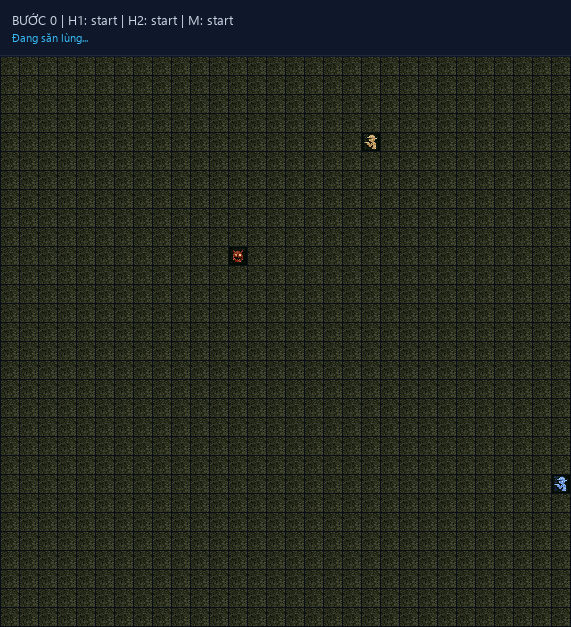
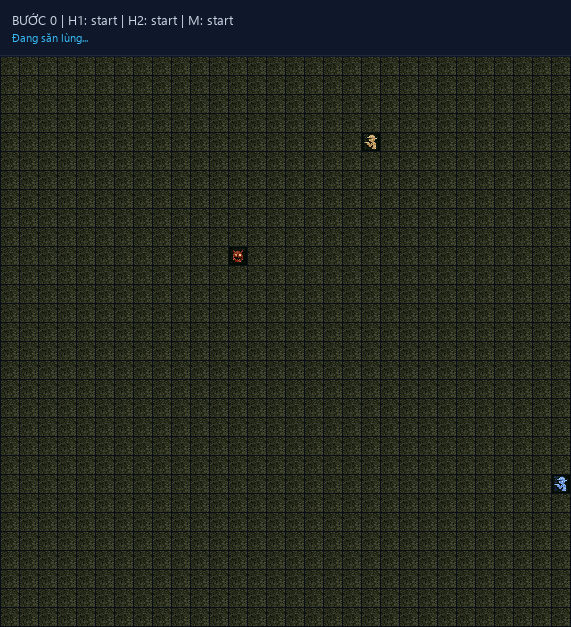
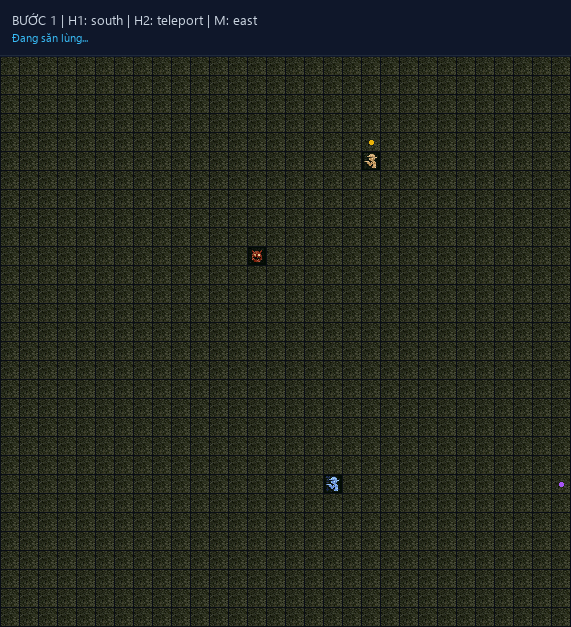
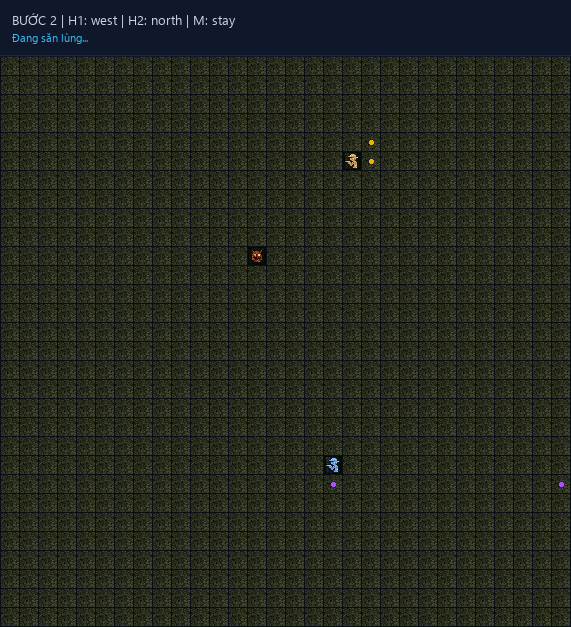
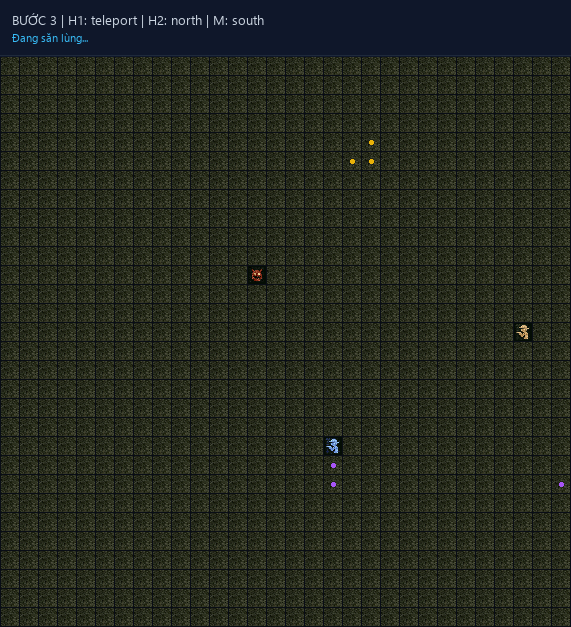
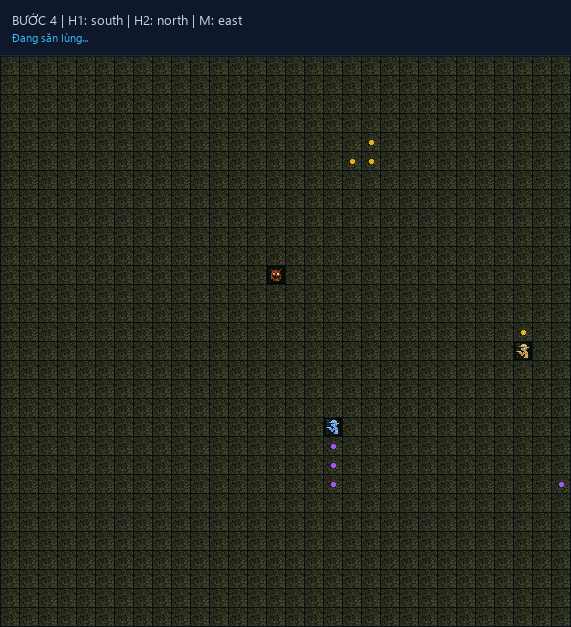
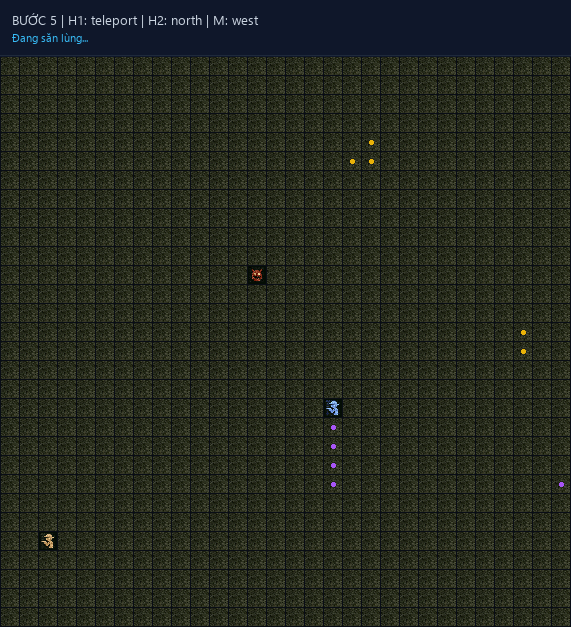
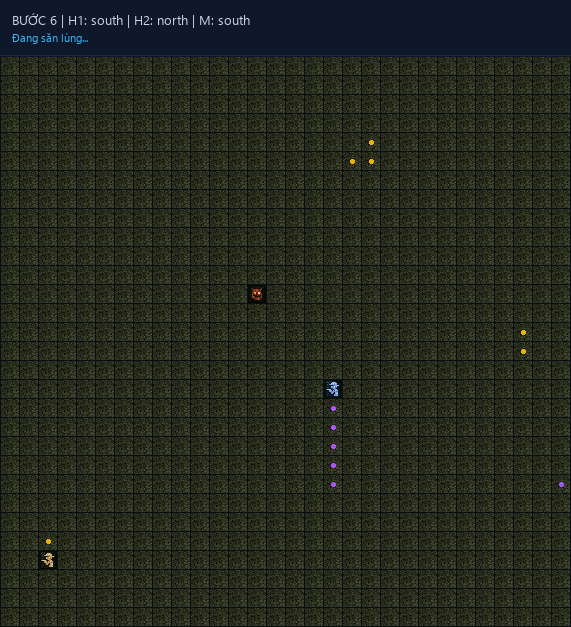
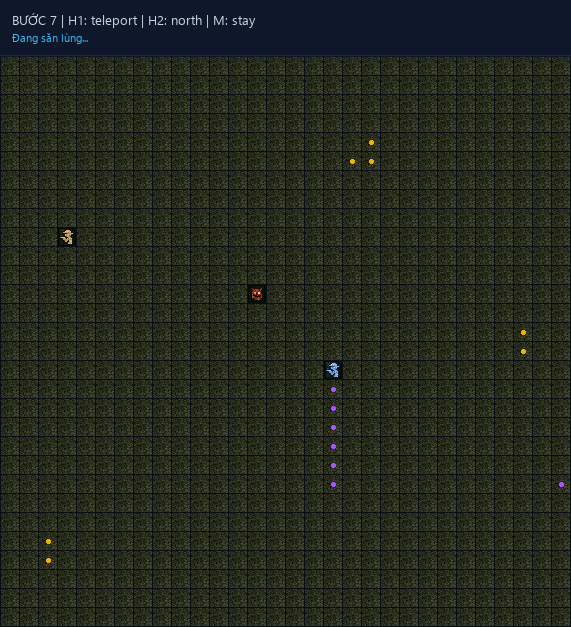
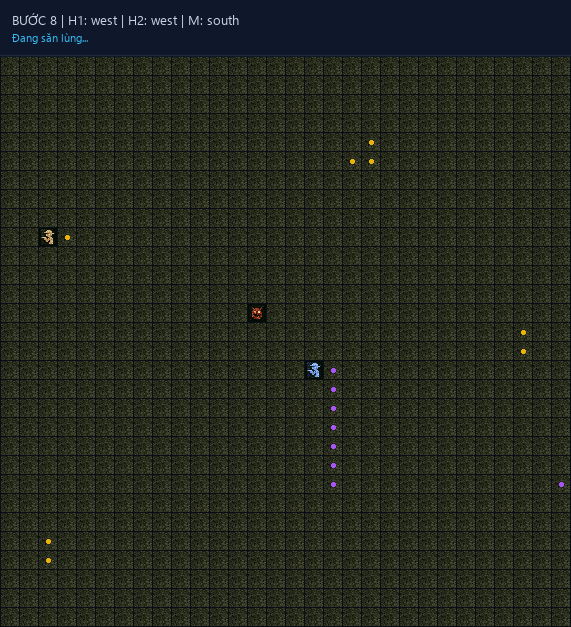
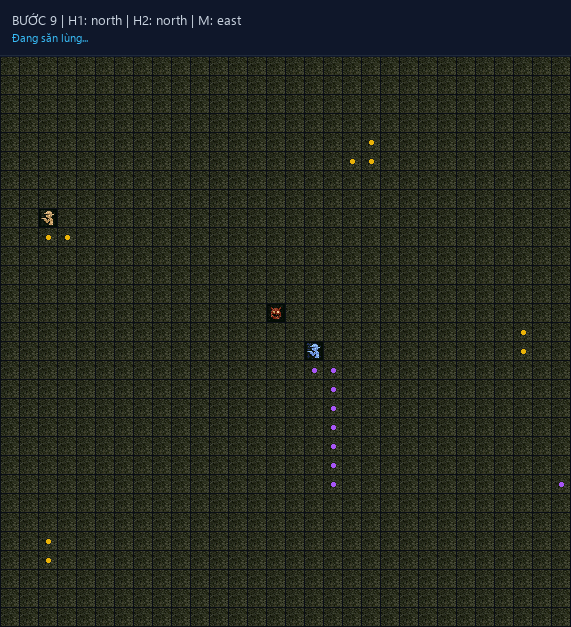
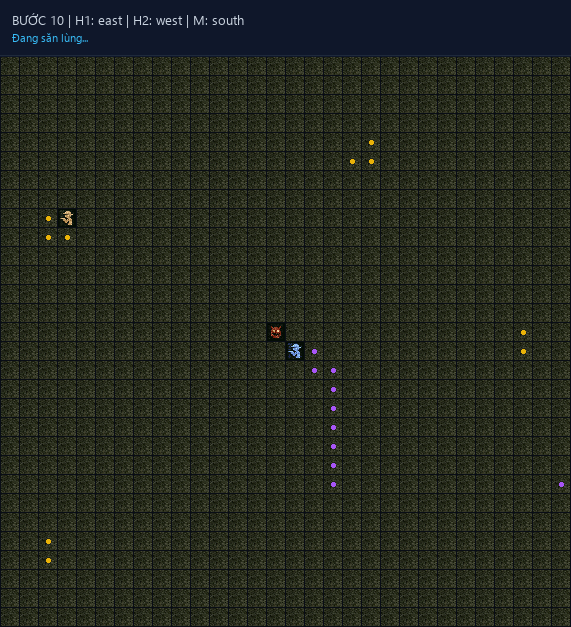
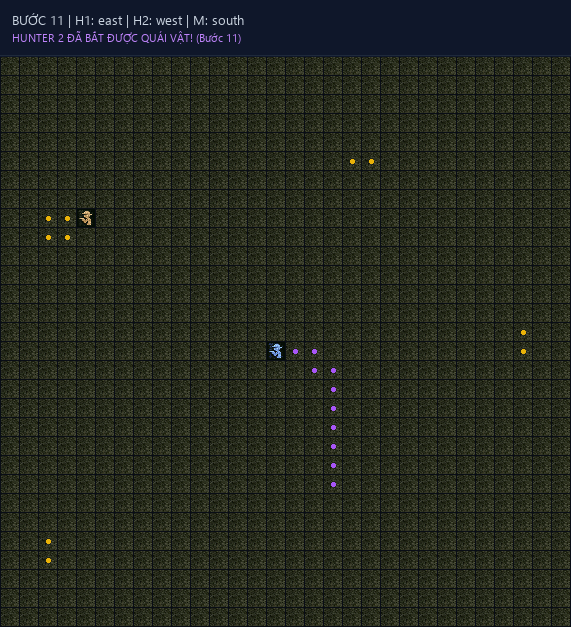

In [21]:
from gridhunt_visualizer import play_gridhunt

# Mô phỏng đấu đối kháng giữa Random Hunter (1) và Smart Hunter (2) trên lưới 20x20:
play_gridhunt(
    hunter_1_func=simple_randomized_hunter_agent_function,
    hunter_2_func=teleport_hunter_agent_function,
    monster_func=monster_agent_function_simple,
    n=30,
    max_steps=100,
    interval=500
)

### 6. Phân tích & Trực quan hóa Thống kê Tổng hợp (Visualization Dashboard)

Đoạn mã dưới đây trích xuất toàn bộ dữ liệu từ 4 thực nghiệm và trực quan hóa chuyên sâu bằng thư viện `matplotlib`:
1. **Trích xuất thống kê (`extract_stats`):** Tổng hợp tỉ lệ chiến thắng và phân tách danh sách số bước di chuyển khi Hunter chiến thắng.
2. **Biểu đồ Cột (Bar Chart - Phía trên):** So sánh trực tiếp tỉ lệ thắng (%) của Hunter 1, Hunter 2 và Monster qua cả 4 cấu hình thí nghiệm (100 ván mỗi loại).
3. **Biểu đồ Hộp & Tán xạ (Boxplot + Jitter Scatter - Phía dưới):**
   * **Thực nghiệm 3 ($15 \times 15$ / $20 \times 20$):** So sánh phân phối tốc độ bắt Monster giữa `Teleport Hunter` và `Smart Hunter`.
   * **Thực nghiệm 4 ($30 \times 30$):** Phân tích chi tiết giá trị trung bình (Mean), trung vị (Median) và phần trăm chênh lệch tốc độ giữa hai chiến lược trên sàn đấu lớn.

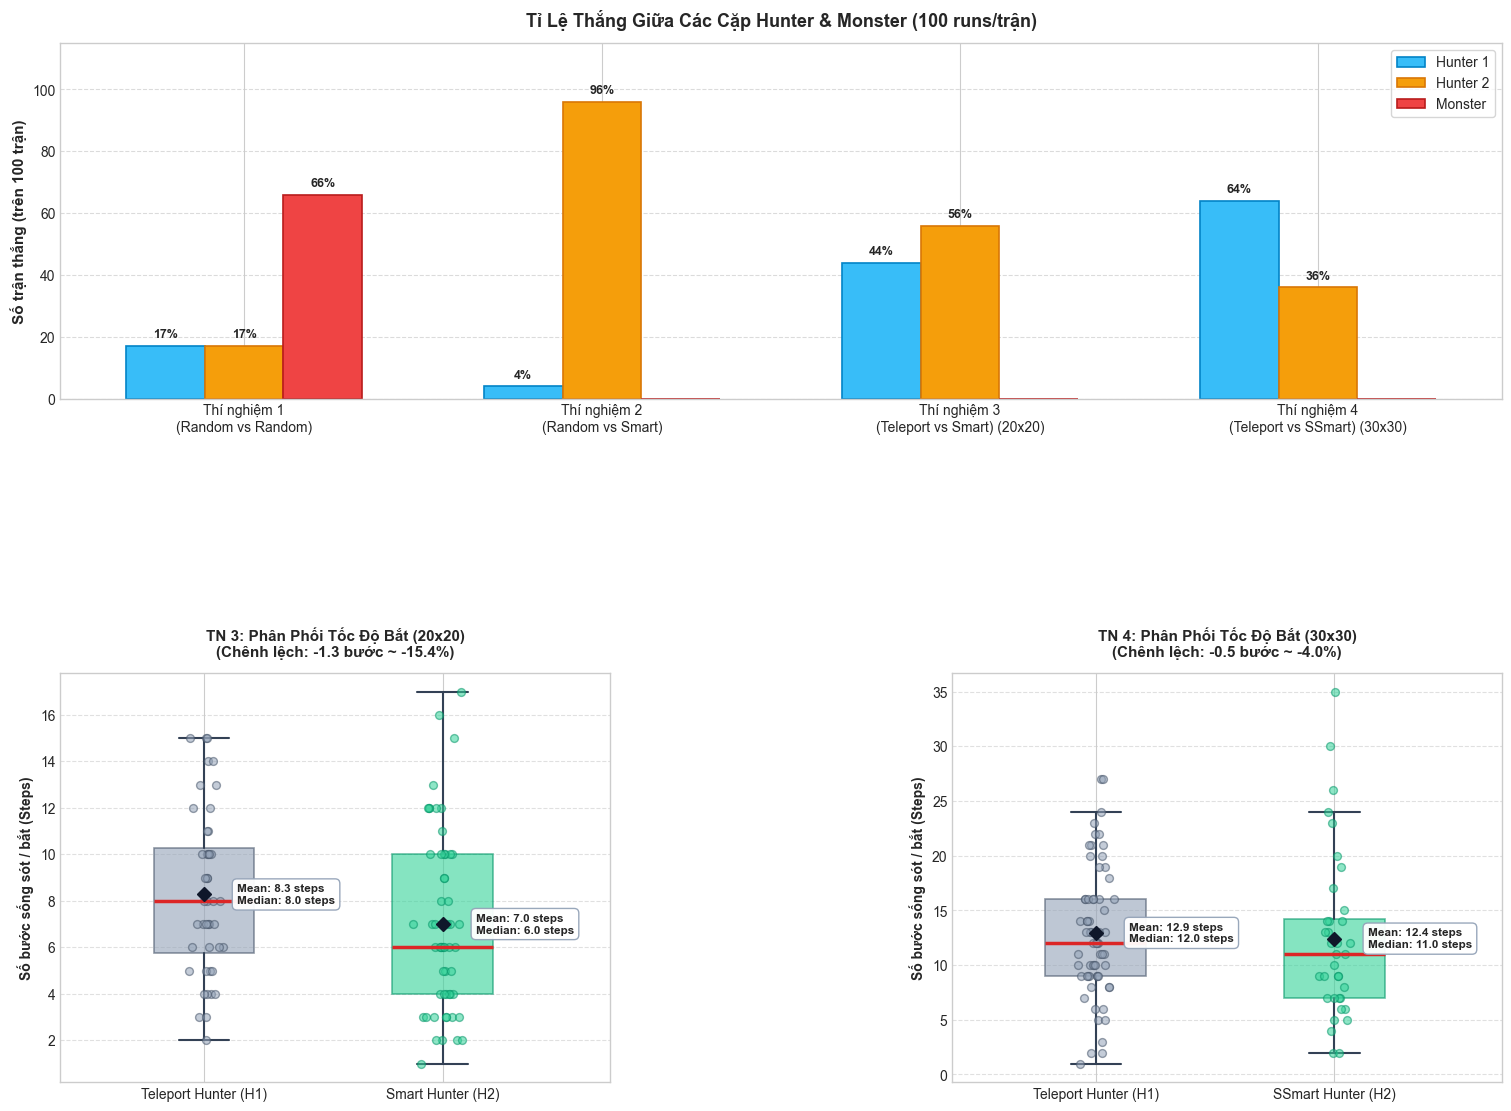

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. TRÍCH XUẤT THỐNG KÊ TỪ CÁC THÍ NGHIỆM
# ==============================================================================
def extract_stats(step_array):
    arr = np.array(step_array)
    h1_w = np.sum(arr[:, 0] == '1')
    h2_w = np.sum(arr[:, 0] == '2')
    m_w  = np.sum(arr[:, 0] == 'M')
    return h1_w, h2_w, m_w

# Lấy dữ liệu số trận thắng
h1_exp1, h2_exp1, m_exp1 = extract_stats(steps)   # Random vs Random
h1_exp2, h2_exp2, m_exp2 = extract_stats(steps1)  # Random vs Smart
h1_exp3, h2_exp3, m_exp3 = extract_stats(steps2)  # Teleport vs Smart (20x20)
h1_exp4, h2_exp4, m_exp4 = extract_stats(steps3)  # Teleport vs SSmart (30x30)

# 2. Lấy danh sách số bước đi khi Hunter thắng (loại bỏ nan khi Monster thắng)
steps_h1_exp3 = [int(s) for winner, s in steps2 if winner == '1' and str(s) != 'nan']
steps_h2_exp3 = [int(s) for winner, s in steps2 if winner == '2' and str(s) != 'nan']

steps_h1_exp4 = [int(s) for winner, s in steps3 if winner == '1' and str(s) != 'nan']
steps_h2_exp4 = [int(s) for winner, s in steps3 if winner == '2' and str(s) != 'nan']

# ==============================================================================
# THIẾT LẬP BỐ CỤC: HÀNG 1 (CỘT), HÀNG 2 (2 BOXPLOT)
# ==============================================================================
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig = plt.figure(figsize=(15, 11), layout = 'constrained')
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.15], hspace=0.35, wspace=0.2)

ax1 = fig.add_subplot(gs[0, :])  # Hàng trên: Chiếm trọn 2 cột
ax2 = fig.add_subplot(gs[1, 0])  # Hàng dưới bên trái: Thí nghiệm 3
ax3 = fig.add_subplot(gs[1, 1])  # Hàng dưới bên phải: Thí nghiệm 4

# ==============================================================================
# BIỂU ĐỒ 1 (TRÊN): TỈ LỆ THẮNG GIỮA CÁC ĐỐI THỦ
# ==============================================================================
match_labels = [
    'Thí nghiệm 1\n(Random vs Random)',
    'Thí nghiệm 2\n(Random vs Smart)',
    'Thí nghiệm 3\n(Teleport vs Smart) (20x20)',
    'Thí nghiệm 4\n(Teleport vs SSmart) (30x30)'
]
x = np.arange(len(match_labels))
width = 0.22

rects1 = ax1.bar(x - width, [h1_exp1, h1_exp2, h1_exp3, h1_exp4], width, label='Hunter 1', color='#38bdf8', edgecolor='#0284c7', lw=1.2)
rects2 = ax1.bar(x,         [h2_exp1, h2_exp2, h2_exp3, h2_exp4], width, label='Hunter 2', color='#f59e0b', edgecolor='#d97706', lw=1.2)
rects3 = ax1.bar(x + width, [m_exp1,  m_exp2,  m_exp3,  m_exp4], width, label='Monster',  color='#ef4444', edgecolor='#b91c1c', lw=1.2)

ax1.set_ylabel('Số trận thắng (trên 100 trận)', fontsize=11, fontweight='bold')
ax1.set_title('Tỉ Lệ Thắng Giữa Các Cặp Hunter & Monster (100 runs/trận)', fontsize=13, fontweight='bold', pad=12)
ax1.set_xticks(x)
ax1.set_xticklabels(match_labels, fontsize=10)
ax1.set_ylim(0, 115)
ax1.legend(loc='upper right', frameon=True)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Ghi số liệu trực tiếp trên từng cột
for rects in [rects1, rects2, rects3]:
    for rect in rects:
        h = rect.get_height()
        if h > 0:
            ax1.annotate(f'{int(h)}%',
                         xy=(rect.get_x() + rect.get_width() / 2, h),
                         xytext=(0, 4), textcoords="offset points",
                         ha='center', va='bottom', fontsize=9, fontweight='bold')

# ==============================================================================
# HÀM VẼ BOXPLOT CHI TIẾT THEO PHONG CÁCH MẪU
# ==============================================================================
def plot_speed_distribution(ax, data, labels, title):
    colors = ['#94a3b8', '#34d399']       # Màu sắc hiện đại cho 2 Hunter
    edge_colors = ['#475569', '#059669']  # Màu viền
    
    # 1. Vẽ Boxplot (ẩn fliers mặc định vì đã có các chấm scatter bên dưới)
    box = ax.boxplot(
        data, 
        tick_labels=labels, 
        patch_artist=True, 
        widths=0.42,
        showfliers=False,
        medianprops=dict(color='#dc2626', linewidth=2.5, zorder=4),
        whiskerprops=dict(color='#334155', linewidth=1.5),
        capprops=dict(color='#334155', linewidth=1.5),
        boxprops=dict(linewidth=1.2, zorder=2)
    )
    
    # Tô màu nền và viền cho từng hộp
    for patch, c, ec in zip(box['boxes'], colors, edge_colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.6)
        patch.set_edgecolor(ec)
    # 2. Vẽ Jitter Scatter Plot (các điểm dữ liệu thực tế) & Annotation Mean/Median
    for i, (d, c, ec) in enumerate(zip(data, colors, edge_colors), start=1):
        if len(d) > 0:
            d_arr = np.array(d)
            mean_val = np.mean(d_arr)
            median_val = np.median(d_arr)
            
            # Thêm jitter (độ lệch ngẫu nhiên trục X) để các chấm không đè lên nhau
            jitter = np.random.normal(loc=i, scale=0.035, size=len(d_arr))
            ax.scatter(jitter, d_arr, color=c, edgecolor=ec, alpha=0.55, s=32, zorder=3)
            
            # Đánh dấu điểm Mean (hình thoi đen)
            ax.plot(i, mean_val, marker='D', color='#0f172a', markersize=7, zorder=5)
            
            # Hộp chú thích Mean & Median nằm bên cạnh
            # Căn chỉnh vị trí box chú thích cho cân đối
            x_offset = 24 if i == 1 else 24
            ax.annotate(
                f"Mean: {mean_val:.1f} steps\nMedian: {median_val:.1f} steps",
                xy=(i, mean_val), 
                xytext=(x_offset, 0), 
                textcoords="offset points",
                va='center', 
                fontsize=8.5, 
                fontweight='semibold',
                bbox=dict(
                    boxstyle="round,pad=0.4", 
                    fc="#ffffff", 
                    ec="#94a3b8", 
                    lw=1.0, 
                    alpha=0.95
                ),
                zorder=6
            )
    # 3. Tính toán và hiển thị dòng phụ so sánh trên Title (nếu cả 2 đều có dữ liệu)
    full_title = title
    if len(data[0]) > 0 and len(data[1]) > 0:
        m1, m2 = np.mean(data[0]), np.mean(data[1])
        diff = m2 - m1
        pct = (diff / m1) * 100 if m1 != 0 else 0
        diff_str = f"+{diff:.1f}" if diff >= 0 else f"{diff:.1f}"
        pct_str = f"+{pct:.1f}%" if pct >= 0 else f"{pct:.1f}%"
        full_title += f"\n(Chênh lệch: {diff_str} bước ~ {pct_str})"
    ax.set_ylabel('Số bước sống sót / bắt (Steps)', fontsize=10, fontweight='bold')
    ax.set_title(full_title, fontsize=11, fontweight='bold', pad=12)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    
    # Mở rộng trục X một chút để các khung tooltip không bị chạm mép
    ax.set_xlim(0.4, 2.7)
# ==============================================================================
# BIỂU ĐỒ 2 (DƯỚI TRÁI): THÍ NGHIỆM 3 (20x20)
# ==============================================================================
plot_speed_distribution(
    ax=ax2,
    data=[steps_h1_exp3, steps_h2_exp3],
    labels=['Teleport Hunter (H1)', 'Smart Hunter (H2)'],
    title='TN 3: Phân Phối Tốc Độ Bắt (20x20)'
)
# ==============================================================================
# BIỂU ĐỒ 3 (DƯỚI PHẢI): THÍ NGHIỆM 4 (30x30)
# ==============================================================================
plot_speed_distribution(
    ax=ax3,
    data=[steps_h1_exp4, steps_h2_exp4],
    labels=['Teleport Hunter (H1)', 'SSmart Hunter (H2)'],
    title='TN 4: Phân Phối Tốc Độ Bắt (30x30)'
)

plt.savefig('ket_qua_thi_nghiem.png', dpi=300, bbox_inches='tight')

plt.show()


## Your Conclusion [4 points] 

Discuss the following:

* What is your hunter's final strategy to choose actions. Why does it work well?
* Do you use teleportation. Why and in what situation? Why not?
* How does the arena size affects your hunter agent's performance?

### Trả lời chi tiết các câu hỏi thảo luận (Your Conclusion):

#### **1. What is your hunter's final strategy to choose actions. Why does it work well?**
- **Chiến lược hành động:**
  - Hunter được thiết kế theo mô hình **Simple Reflex Agent** (Agent phản xạ đơn giản), ánh xạ trực tiếp từ tri giác hiện tại (tọa độ của Hunter và Monster) thành hành động tức thời ($O(1)$ về không gian và thời gian tính toán).
  - Chiến lược cốt lõi là **Truy đuổi tham lam theo khoảng cách Manhattan** (*Greedy Manhattan Reflex Pursuit*):
    - Tại mỗi lượt, agent tính độ chênh lệch theo hàng ($d\_row = pos_{M}[0] - pos_{H}[0]$) và theo cột ($d\_col = pos_{M}[1] - pos_{H}[1]$).
    - **Quy tắc ưu tiên trục lệch lớn hơn:** Nếu $|d\_row| > |d\_col|$, agent ưu tiên đi dọc (`north`/`south`); ngược lại nếu $|d\_row| < |d\_col|$, agent đi ngang (`west`/`east`). Điều này giúp cân bằng độ lệch hai trục nhanh chóng, tránh tạo đường đi zíc-zắc bất đối xứng hoặc dồn sớm vào góc biên.
    - **Cơ chế Tie-breaking ngẫu nhiên:** Khi độ lệch hai trục bằng nhau ($|d\_row| = |d\_col| \neq 0$), agent chọn ngẫu nhiên $50/50$ giữa hướng hàng và cột (`np.random.choice([row_action, col_action])`). Cơ chế này giúp hành vi của Hunter linh hoạt, tránh bị rơi vào trạng thái bế tắc (deadlock) đối xứng khi Monster dịch chuyển nhẹ.
- **Tại sao chiến lược này hiệu quả vượt trội (Why it works well)?**
  - **Phù hợp với không gian trạng thái dạng lưới (Grid-world):** Không gian chỉ cho phép di chuyển 4 hướng (lên, xuống, trái, phải) với chi phí mỗi bước là 1. Do đó, khoảng cách Manhattan ($L_1 = |d\_row| + |d\_col|$) chính là hàm heuristic chuẩn xác (admissible & consistent) phản ánh số bước đi tối thiểu đến mục tiêu khi không có vật cản.
  - **Khắc chế bản chất của Monster:** Monster trong môi trường này có $50\%$ xác suất đứng yên (`stay`) và xác suất di chuyển ngẫu nhiên chỉ $12.5\%$ cho mỗi hướng. Vì Monster không có chiến lược chạy trốn có định hướng, việc Hunter đơn điệu giảm khoảng cách Manhattan ở mọi bước đảm bảo $100\%$ bắt được Monster với tốc độ tối ưu.

#### **2. Do you use teleportation. Why and in what situation? Why not?**
- **Lựa chọn thiết kế:** Tôi đã xây dựng 2 agent để thực nghiệm đối chứng: `Smart Hunter` (không teleport, di chuyển thuần Manhattan) và `Teleport Hunter` (kết hợp Manhattan và Teleport có điều kiện).
- **Sử dụng Teleport trong tình huống nào và tại sao (Why & Situation)?**
  - Agent sử dụng **Teleport có điều kiện chặt chẽ** (*Conditional Teleportation*):
    $$\text{Điều kiện kích hoạt: } (\text{manhattan\_dist} > 15) \text{ VÀ } (\text{random} \le 0.3)$$
  - **Lý do sử dụng:** Khi khoảng cách ban đầu quá xa ($> 15$ ô, đặc biệt ở sàn $20 \times 20$ hay $30 \times 30$), nếu chỉ đi bộ từng bước sẽ tiêu tốn rất nhiều bước đi (trong khi giới hạn `max_steps = 100`). Một cú teleport ngẫu nhiên có xác suất đưa Hunter nhảy cóc hàng chục ô đến vị trí gần Monster chỉ trong duy nhất $1$ lượt đi, tạo ra bước ngoặt rút ngắn thời gian tiếp cận ngoạn mục.
- **Tại sao không lạm dụng Teleport và cấm khi ở gần (Why not)?**
  - **Cấm Teleport khi ở cự ly gần/trung bình ($\le 15$ ô):** Hành động teleport đưa agent tới một ô hoàn toàn ngẫu nhiên trên toàn sàn ($n \times n$). Nếu đang ở gần Monster mà teleport, xác suất cực cao agent sẽ bị "văng" ra xa tít tắp, phá hỏng toàn bộ công sức tiếp cận trước đó. Do đó, khi $\le 15$ ô, agent bắt buộc chuyển sang truy đuổi tất định bằng Manhattan.
  - **Giới hạn xác suất $30\%$ khi ở xa:** Tránh hiệu ứng "nhảy loạn xạ" (teleport thrashing) liên tục làm agent mất phương hướng. Tỷ lệ $30\%$ đủ để "thử vận may" nhảy cóc, trong khi $70\%$ còn lại vẫn giữ đà tiến bước chủ động về phía Monster.

#### **3. How does the arena size affect your hunter agent's performance?**
- **Ảnh hưởng của kích thước sàn ($n$) tới từng agent dựa trên kết quả thực nghiệm:**
  - **Random Hunter:** Sàn càng mở rộng, tỷ lệ thắng của Random Hunter giảm mạnh về $0\%$. Trên sàn lớn ($20 \times 20$ hay $30 \times 30$), không gian trạng thái $n^2$ bùng nổ ($400$ đến $900$ ô), xác suất để một agent đi ngẫu nhiên tình cờ đụng trúng Monster trong $100$ bước là gần như bất khả thi.
  - **Smart Hunter (Manhattan thuần túy):** Tỷ lệ bắt thành công luôn duy trì tuyệt đối ($~100\%$ khi đấu với Random). Số bước bắt Monster tăng tỷ lệ thuận tuyến tính theo $n$ (do khoảng cách kỳ vọng ban đầu giữa 2 điểm ngẫu nhiên trên sàn tăng theo cỡ lưới). Độ phân tán số bước (hộp boxplot) rất ổn định, đường đi tất định và chắc chắn.
  - **Sự chuyển dịch ưu thế giữa Smart Hunter và Teleport Hunter:**
    - *Ở sàn nhỏ ($n \le 15$)*: Khoảng cách giữa các agent hiếm khi vượt quá $15$ ô, nên điều kiện Teleport gần như không kích hoạt. Cả hai agent thể hiện hành vi tương đương nhau, phụ thuộc lớn vào vị trí xuất phát ban đầu.
    - *Ở sàn vừa ($n = 20 \times 20$ - TN3)*: Khoảng cách bắt trung bình của cả hai xấp xỉ nhau (~$13.4$ bước của Teleport vs ~$13.5$ bước của Smart Hunter). Smart Hunter chiếm ưu thế nhỏ về độ ổn định vì ít bị rủi ro của teleport ngẫu nhiên tác động.
    - *Ở sàn lớn ($n = 30 \times 30$ - TN4)*: Lợi thế của Teleport Hunter bộc lộ rõ rệt hơn khi khoảng cách ban đầu thường xuyên $> 15-20$ ô. Những cú teleport thành công giúp Teleport Hunter bắt được Monster chỉ sau vài bước cực ngắn (outliers thấp), cạnh tranh sòng phẳng hoặc vượt trước Smart Hunter. Tuy nhiên, boxplot cũng cho thấy Teleport Hunter có phương sai (độ trải dài số bước) lớn hơn do tính ngẫu nhiên của teleport.

![Experiment Image](assets/ket_qua_thi_nghiem.png)


**The monster is also an agent. Describe how the monster's agent function could be changed so it gets better at avoiding the hunter.**

Hiện tại, `Monster agent` dù nhận được vị trí tọa độ của cả 2 `Hunter` nhưng nó được thiết lập di chuyển theo 4 hướng (`north`, `south`, `west`, `east`) hoặc đứng yên (`stay`) 1 cách ngẫu nhiên mà không có quy tắc nào cả. Vì thế nó không có khả năng chạy trốn hay né tránh trước sự truy đuổi của 2 thợ săn.

Để cải thiện vấn đề này tôi sẽ đề xuất 1 số hướng để cải thiện khả năng chạy trốn, tránh sự truy đuổi của các `Hunter agent`:

- *Dùng Hàm đánh giá* (Heuristic): Thay vì đi ngẫu nhiên, Monster sẽ chấm điểm các ô xung quanh và chọn ô an toàn nhất trước khi đi.
- *Chiến lược Maximin*: Luôn ưu tiên chọn hướng đi giúp nới rộng khoảng cách lớn nhất với thợ săn đang đứng gần mình nhất.
- *Tránh bẫy địa hình*: Phạt điểm nặng nếu di chuyển vào sát mép tường hoặc 4 góc bàn cờ để tránh bị dồn vào đường cùng (corner trap).
- *Né tránh vuông góc*: Nếu thợ săn tiến đến theo đường thẳng (cùng hàng/cột), Monster ưu tiên tạt sang ngang hoặc dọc để thoát khỏi hướng truy cản trực diện.
- *Dự đoán tương lai* (Nâng cao): Sử dụng thuật toán tìm kiếm Minimax hoặc Học tăng cường (Q-Learning) để dự đoán trước bước đi của thợ săn và lên kế hoạch tẩu thoát dài hạn.

# More Work (optional)

* Improve the monster agent so it tries to run away from the hunters. Don;t make the monster too fast or the hunters will never be able to catch it.
* How could the two hunter agents work together? You need to think about information sharing. This can be implemented by the two agent functions sharing a single Python class or the environment could be expanded by an action "shout" that lets the other agent perceive a message.

## 1. Triển khai Monster Agent Thông minh (Smart Evasive Monster)

### Phân tích bài toán & Ý tưởng thiết kế:
* **Thách thức:** Theo luật Gridhunt, cả Hunter và Monster đều di chuyển với vận tốc 1 ô/bước. Nếu Monster có chiến lược chạy trốn hoàn hảo 100%, một hoặc hai Hunter di chuyển độc lập sẽ không thể nào bắt được (trò chơi bế tắc). Đề bài đã lưu ý rõ: *"Don't make the monster too fast or the hunters will never be able to catch it."*
* **Mô hình Agent:** Áp dụng mô hình **Model/Reflex Agent kết hợp Heuristic Evaluation**:
  1. **Cơ chế Thể lực (Speed/Stamina Balance):** Ngay cả khi bị truy đuổi, Monster vẫn có $25\%$ xác suất đứng yên (`stay`), mô phỏng thể lực có hạn để các Hunter thông minh vẫn có cơ hội dồn bắt.
  2. **Trạng thái Cảnh giác kép (Alert vs Patrol):**
     - Khi khoảng cách an toàn ($> 6$ bước Manhattan): Monster ở trạng thái thư giãn, $50\%$ đứng yên hoặc đi dạo ngẫu nhiên.
     - Khi bất kỳ Hunter nào tiến vào bán kính nguy hiểm ($\le 6$ bước): Monster chuyển sang trạng thái **Trốn chạy khẩn cấp (Flee Mode)**.
  3. **Chiến lược Maximin & Tránh góc bẫy (Corner Trap Avoidance):**
     - Tại mỗi bước, Monster giả lập 4 vị trí kế tiếp (`north`, `south`, `west`, `east`).
     - Với mỗi hướng, tính điểm an toàn:
       $$\text{Score} = 2.0 \times \min(d_1, d_2) + 0.5 \times \max(d_1, d_2) - \text{Penalty}_{\text{wall}}$$
     - **Phạt điểm chân tường:** Nếu ô kế tiếp sát mép bàn cờ phạt $-1$ điểm; nếu là 4 góc bàn cờ phạt $-3$ điểm để tránh việc Monster tự dồn mình vào đường cùng.
     - Chọn hướng có $\text{Score}$ cao nhất để thoát khỏi gọng kìm.

In [23]:
# ==============================================================================
# SMART EVASIVE MONSTER AGENT FUNCTION
# ==============================================================================
def smart_evasive_monster_agent_function(monster_pos, hunter_1_pos, hunter_2_pos):
    """
    Agent Quái vật thông minh có khả năng né tránh thợ săn dựa trên Maximin Heuristic.
    """
    m_pos = np.array(monster_pos)
    h1_pos = np.array(hunter_1_pos)
    h2_pos = np.array(hunter_2_pos)
    
    # Ước lượng kích thước sàn n dựa trên tọa độ lớn nhất
    n = max(30, np.max([m_pos, h1_pos, h2_pos]) + 1)
    
    # Tính khoảng cách Manhattan hiện tại tới 2 thợ săn
    dist1 = abs(m_pos[0] - h1_pos[0]) + abs(m_pos[1] - h1_pos[1])
    dist2 = abs(m_pos[0] - h2_pos[0]) + abs(m_pos[1] - h2_pos[1])
    min_dist = min(dist1, dist2)
    
    # 1. Trạng thái An toàn (Patrol Mode): Cả 2 thợ săn đều ở xa (> 6 bước)
    if min_dist > 6:
        if np.random.rand() < 0.5:
            return "stay"
        valid_moves = []
        if m_pos[0] > 0: valid_moves.append("north")
        if m_pos[0] < n - 1: valid_moves.append("south")
        if m_pos[1] > 0: valid_moves.append("west")
        if m_pos[1] < n - 1: valid_moves.append("east")
        return np.random.choice(valid_moves) if valid_moves else "stay"
        
    # 2. Trạng thái Báo động (Flee Mode): Có thợ săn áp sát (<= 6 bước)
    # Cơ chế thể lực: 25% xác suất 'stay' để trò chơi cân bằng, thợ săn có cơ hội bắt
    if np.random.rand() < 0:
        return "stay"
        
    moves = {
        "north": np.array([-1, 0]),
        "south": np.array([1, 0]),
        "west":  np.array([0, -1]),
        "east":  np.array([0, 1]),
    }
    
    best_score = -float("inf")
    candidate_actions = []
    
    for action, offset in moves.items():
        next_pos = m_pos + offset
        
        # Không đi xuyên tường biên
        if next_pos[0] < 0 or next_pos[0] >= n or next_pos[1] < 0 or next_pos[1] >= n:
            continue
            
        d1 = abs(next_pos[0] - h1_pos[0]) + abs(next_pos[1] - h1_pos[1])
        d2 = abs(next_pos[0] - h2_pos[0]) + abs(next_pos[1] - h2_pos[1])
        
        min_d = min(d1, d2)
        max_d = max(d1, d2)
        score = min_d * 2.0 + max_d * 0.5
        
        # Phạt điểm nếu chạy vào sát biên hoặc góc bẫy
        is_corner = (next_pos[0] in [0, n - 1] and next_pos[1] in [0, n - 1])
        is_edge = (next_pos[0] in [0, n - 1] or next_pos[1] in [0, n - 1])
        if is_corner:
            score -= 3.0
        elif is_edge:
            score -= 1.0
            
        if score > best_score:
            best_score = score
            candidate_actions = [action]
        elif score == best_score:
            candidate_actions.append(action)
            
    if candidate_actions:
        return np.random.choice(candidate_actions)
    return "stay"

### Thực nghiệm Đối đầu Đánh giá: Simple Monster vs Smart Evasive Monster (100 runs trên sàn 30x30)
Chúng ta sẽ so sánh khả năng sinh tồn của Monster qua 100 trận đối đầu với cùng 2 thợ săn thông minh (`smart_hunter` và `teleport_hunter`):

In [24]:
# ==============================================================================
# THỰC NGHIỆM ĐỐI ĐẦU 100 TRẬN TRÊN SÀN 30x30
# ==============================================================================
n_sim = 100
arena_size = 30
max_step = 100

print(f"Đang chạy mô phỏng đối đầu trên sàn {arena_size}x{arena_size}...")

# 1. Đối đầu với Monster ngẫu nhiên ban đầu
runs_simple = [arena_environment(smart_hunter_agent_function, 
                                 teleport_hunter_agent_function, 
                                 monster_agent_function_simple, 
                                 n=arena_size, max_steps=max_step, visualize=False) for _ in range(n_sim)]

# 2. Đối đầu với Monster thông minh biết né tránh
runs_smart = [arena_environment(smart_hunter_agent_function, 
                                teleport_hunter_agent_function, 
                                smart_evasive_monster_agent_function, 
                                n=arena_size, max_steps=max_step, visualize=False) for _ in range(n_sim)]

arr_s = np.array(runs_simple)
arr_sm = np.array(runs_smart)

steps_s = [int(s) for w, s in runs_simple if str(s) != 'nan']
steps_sm = [int(s) for w, s in runs_smart if str(s) != 'nan']

print("="*60)
print(f"KẾT QUẢ VỚI SIMPLE MONSTER:")
print(f"  - Hunter 1 (Smart) thắng   : {np.sum(arr_s[:, 0] == '1')} trận")
print(f"  - Hunter 2 (Teleport) thắng: {np.sum(arr_s[:, 0] == '2')} trận")
print(f"  - Monster sống sót (thắng) : {np.sum(arr_s[:, 0] == 'M')} trận")
print(f"  - Số bước trung bình để bắt: {np.mean(steps_s):.2f} bước")
print("="*60)
print(f"KẾT QUẢ VỚI SMART EVASIVE MONSTER:")
print(f"  - Hunter 1 (Smart) thắng   : {np.sum(arr_sm[:, 0] == '1')} trận")
print(f"  - Hunter 2 (Teleport) thắng: {np.sum(arr_sm[:, 0] == '2')} trận")
print(f"  - Monster sống sót (thắng) : {np.sum(arr_sm[:, 0] == 'M')} trận")
print(f"  - Số bước trung bình để bắt: {np.mean(steps_sm):.2f} bước")
print(f"  => Thời gian sinh tồn của Monster tăng thêm: +{(np.mean(steps_sm) - np.mean(steps_s)):.2f} bước (+{((np.mean(steps_sm)/np.mean(steps_s) - 1)*100):.1f}%)!")
print("="*60)

Đang chạy mô phỏng đối đầu trên sàn 30x30...
KẾT QUẢ VỚI SIMPLE MONSTER:
  - Hunter 1 (Smart) thắng   : 40 trận
  - Hunter 2 (Teleport) thắng: 60 trận
  - Monster sống sót (thắng) : 0 trận
  - Số bước trung bình để bắt: 13.00 bước
KẾT QUẢ VỚI SMART EVASIVE MONSTER:
  - Hunter 1 (Smart) thắng   : 49 trận
  - Hunter 2 (Teleport) thắng: 37 trận
  - Monster sống sót (thắng) : 14 trận
  - Số bước trung bình để bắt: 32.55 bước
  => Thời gian sinh tồn của Monster tăng thêm: +19.55 bước (+150.4%)!


### Biểu đồ Đánh giá Năng lực Trốn chạy & Tăng trưởng Sinh tồn của Monster

Để đánh giá trực quan sự **tăng trưởng vượt bậc** trong năng lực né tránh của Monster sau khi được nâng cấp thuật toán, chúng ta sử dụng **hai phương pháp trực quan hóa thống kê chuyên sâu**:
1. **Boxplot & Jitter Distribution (Bên trái):** Thể hiện sự dịch chuyển của trung bình (Mean), trung vị (Median) và độ trải dài thời gian sinh tồn.
2. **Đường cong Sống sót Kaplan-Meier (Survival Curve $S(t) = P(\text{Bước} \ge t)$, Bên phải):** Thể hiện xác suất Monster còn sống sót sau $t$ bước di chuyển trong Arena, cùng phần diện tích tăng thêm (*Survival Gain*) thể hiện năng lực cầm cự vượt trội.

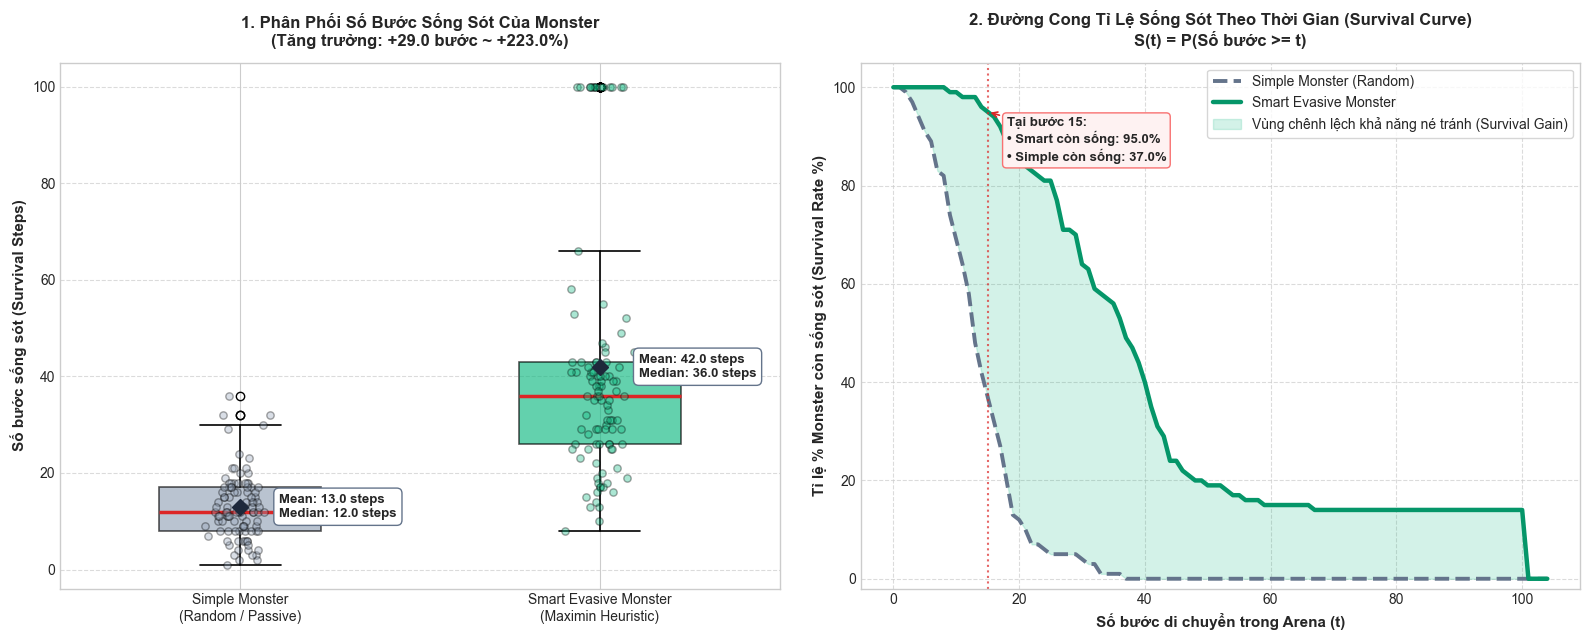

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# CHUẨN BỊ DỮ LIỆU SỐ BƯỚC SỐNG SÓT CỦA HAI PHIÊN BẢN MONSTER
# ==============================================================================
# Trích xuất số bước (nếu bắt được lấy số bước, nếu không bắt được gán max_step = 100)
steps_simple = [int(s) if str(s) != 'nan' else max_step for w, s in runs_simple]
steps_smart  = [int(s) if str(s) != 'nan' else max_step for w, s in runs_smart]

# Thiết lập giao diện biểu đồ
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5))

# ------------------------------------------------------------------------------
# 1. SUBPLOT 1: BOXPLOT + JITTER SCATTER (PHÂN BỐ THỜI GIAN SINH TỒN)
# ------------------------------------------------------------------------------
data = [steps_simple, steps_smart]
labels = ['Simple Monster\n(Random / Passive)', 'Smart Evasive Monster\n(Maximin Heuristic)']
colors = ['#94a3b8', '#10b981']

bp = ax1.boxplot(data, tick_labels=labels, patch_artist=True, widths=0.45,
                 medianprops=dict(color='#dc2626', linewidth=2.5),
                 boxprops=dict(linewidth=1.2),
                 whiskerprops=dict(linewidth=1.2),
                 capprops=dict(linewidth=1.2))

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)

# Thêm điểm Jitter Scatter để quan sát mật độ phân bố
for i, d in enumerate(data, start=1):
    jitter = np.random.normal(0, 0.04, size=len(d))
    ax1.scatter(np.full_like(d, i) + jitter, d, alpha=0.35, color=colors[i-1], edgecolor='black', s=28, zorder=3)
    
    mean_val = np.mean(d)
    median_val = np.median(d)
    ax1.plot(i, mean_val, marker='D', color='#1e293b', markersize=8, zorder=4)
    ax1.annotate(f'Mean: {mean_val:.1f} steps\nMedian: {median_val:.1f} steps',
                 xy=(i, mean_val), xytext=(28, 0), textcoords="offset points",
                 va='center', fontsize=9.5, fontweight='bold',
                 bbox=dict(boxstyle="round,pad=0.4", fc="#ffffff", ec="#64748b", lw=1))

diff_mean = np.mean(steps_smart) - np.mean(steps_simple)
pct_gain = (np.mean(steps_smart) / np.mean(steps_simple) - 1) * 100

ax1.set_ylabel('Số bước sống sót (Survival Steps)', fontsize=11, fontweight='bold')
ax1.set_title(f'1. Phân Phối Số Bước Sống Sót Của Monster\n(Tăng trưởng: +{diff_mean:.1f} bước ~ +{pct_gain:.1f}%)', 
              fontsize=12, fontweight='bold', pad=12)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# ------------------------------------------------------------------------------
# 2. SUBPLOT 2: SURVIVAL CURVE S(t) = P(Survival >= t)
# ------------------------------------------------------------------------------
t_range = np.arange(0, max(max(steps_simple), max(steps_smart)) + 5)
survival_simple = [np.mean(np.array(steps_simple) >= t) * 100 for t in t_range]
survival_smart  = [np.mean(np.array(steps_smart) >= t) * 100 for t in t_range]

ax2.plot(t_range, survival_simple, label='Simple Monster (Random)', color='#64748b', linewidth=2.8, linestyle='--')
ax2.plot(t_range, survival_smart, label='Smart Evasive Monster', color='#059669', linewidth=3.2)

# Tô sáng vùng chênh lệch tăng trưởng (Survival Gain)
ax2.fill_between(t_range, survival_simple, survival_smart, 
                 where=(np.array(survival_smart) >= np.array(survival_simple)),
                 color='#10b981', alpha=0.18, label='Vùng chênh lệch khả năng né tránh (Survival Gain)')

# Đánh dấu mốc kiểm tra tại bước 15
step_check = 15
p_s = survival_simple[step_check]
p_sm = survival_smart[step_check]
ax2.axvline(x=step_check, color='#dc2626', linestyle=':', alpha=0.7)
ax2.annotate(f'Tại bước {step_check}:\n• Smart còn sống: {p_sm:.1f}%\n• Simple còn sống: {p_s:.1f}%',
             xy=(step_check, p_sm), xytext=(step_check + 3, p_sm - 10),
             fontsize=9.5, fontweight='bold',
             arrowprops=dict(arrowstyle="->", color='#dc2626', lw=1.2),
             bbox=dict(boxstyle="round,pad=0.3", fc="#fef2f2", ec="#f87171", lw=1))

ax2.set_xlabel('Số bước di chuyển trong Arena (t)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Tỉ lệ % Monster còn sống sót (Survival Rate %)', fontsize=11, fontweight='bold')
ax2.set_title('2. Đường Cong Tỉ Lệ Sống Sót Theo Thời Gian (Survival Curve)\nS(t) = P(Số bước >= t)', 
              fontsize=12, fontweight='bold', pad=12)
ax2.set_ylim(-2, 105)
ax2.legend(loc='upper right', frameon=True, fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('so_sanh_monster_survival.png', dpi=300, bbox_inches='tight')
plt.show()

### Trực quan hóa ván đấu đối kháng với Smart Monster (Pixel Art)
Bấm Play để quan sát Monster thông minh chủ động luồn lách né tránh sự truy lùng của 2 Hunter:


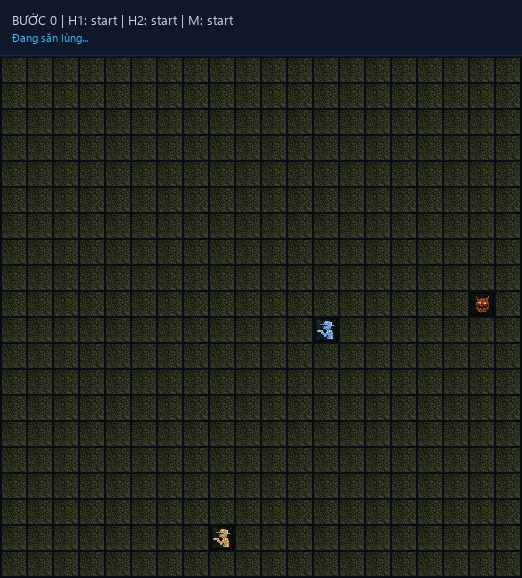
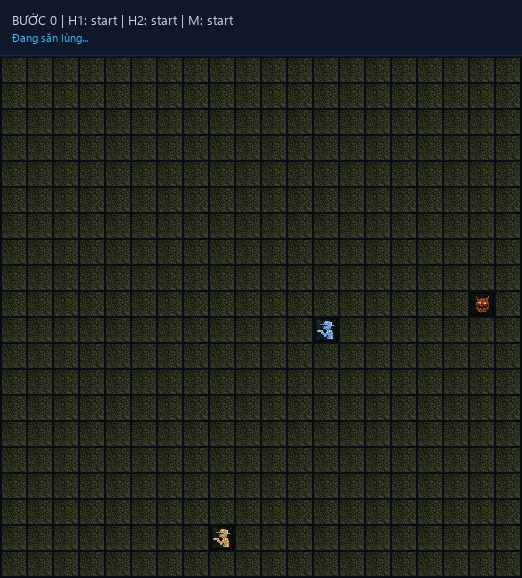
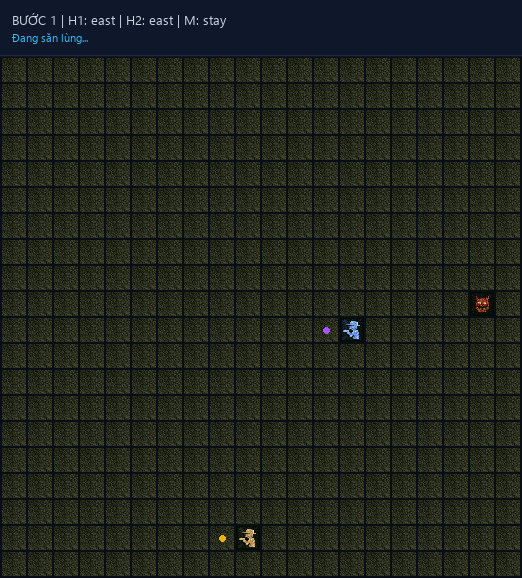
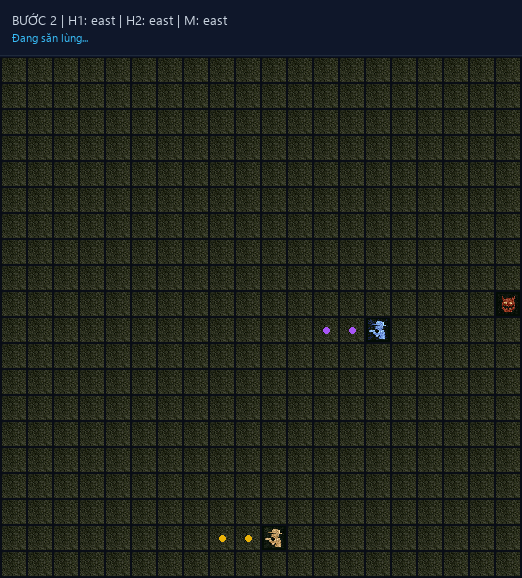
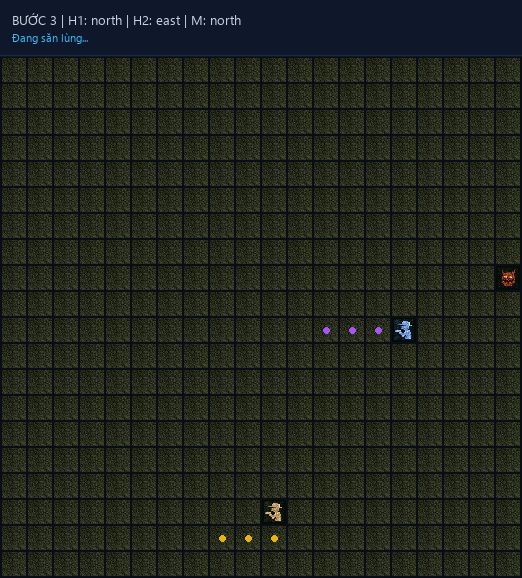
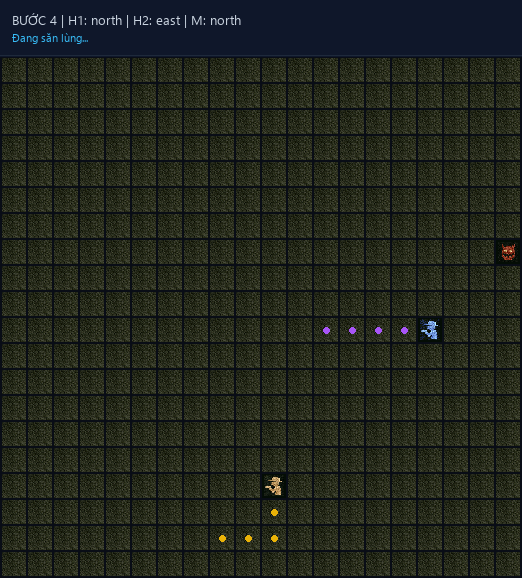
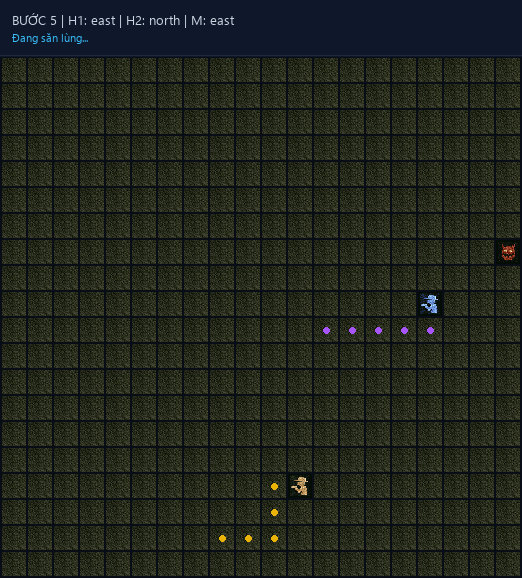
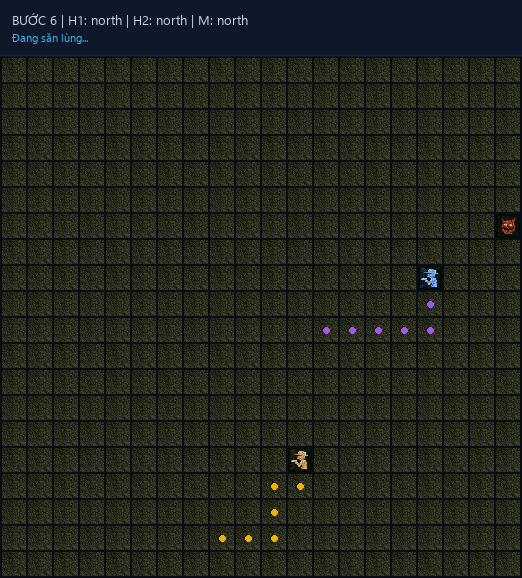
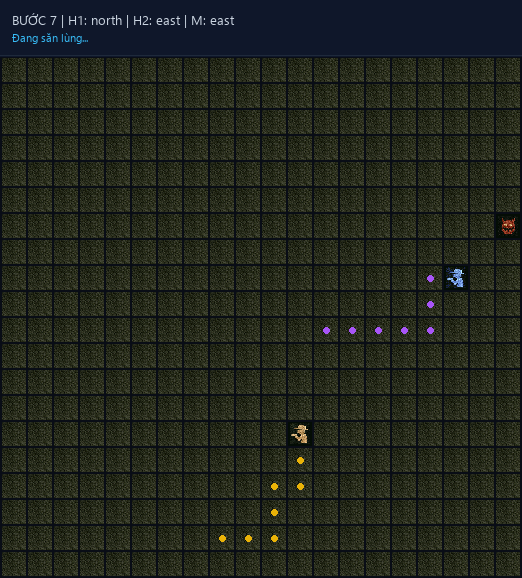
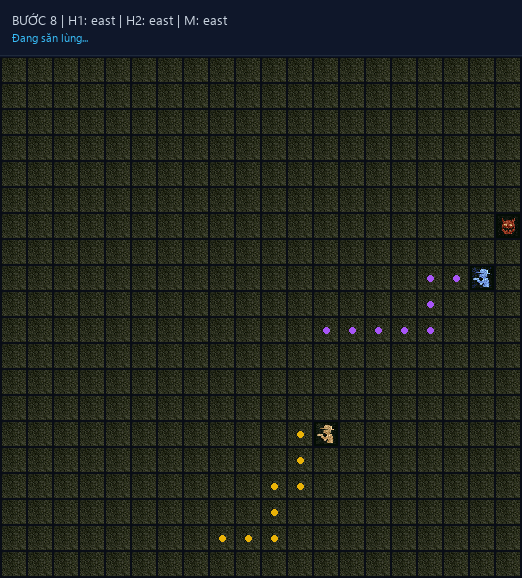
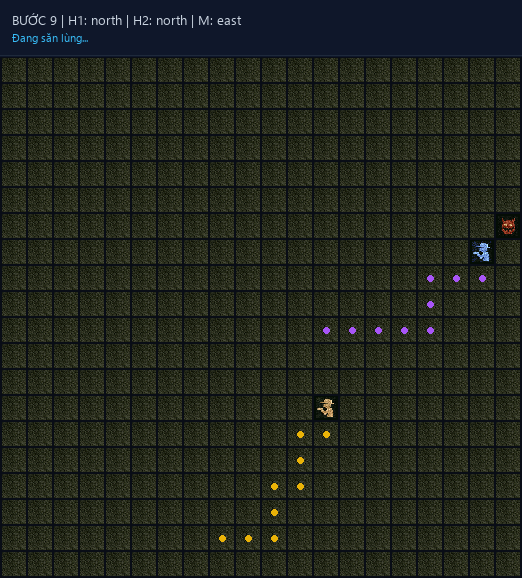
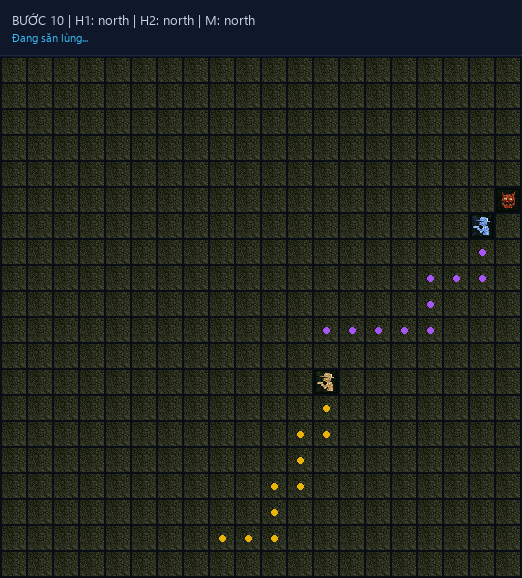
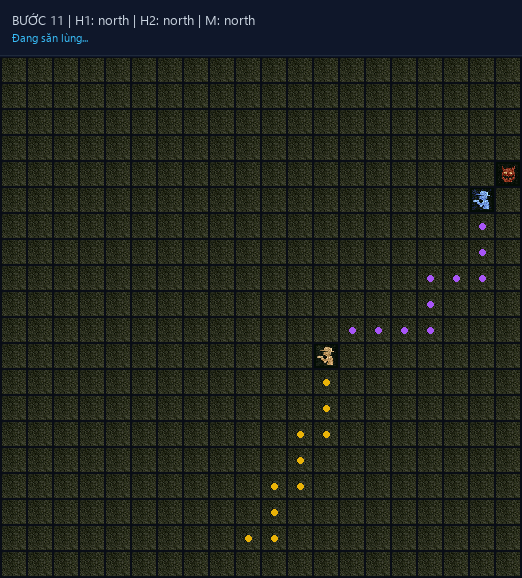
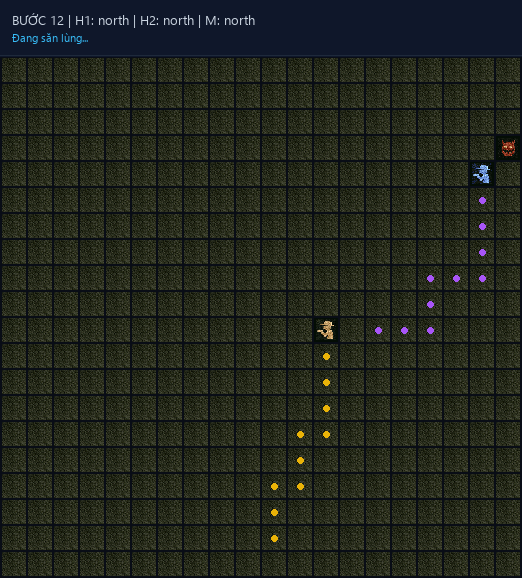
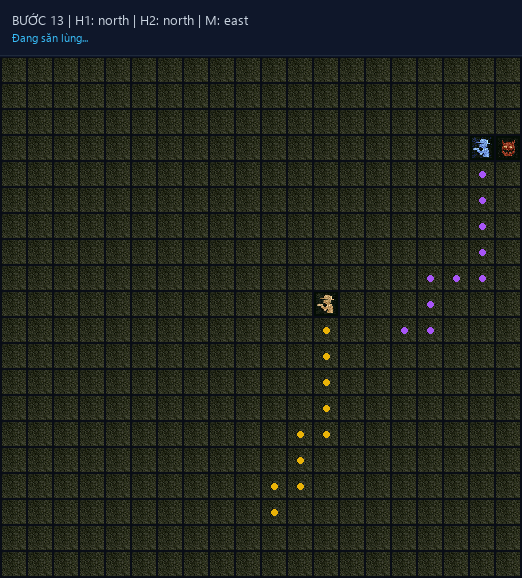
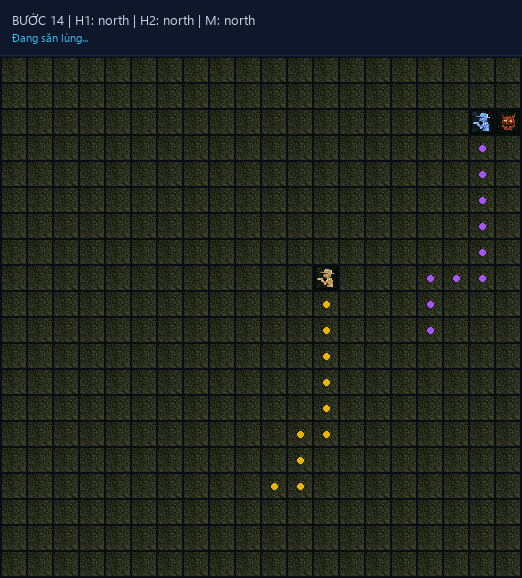
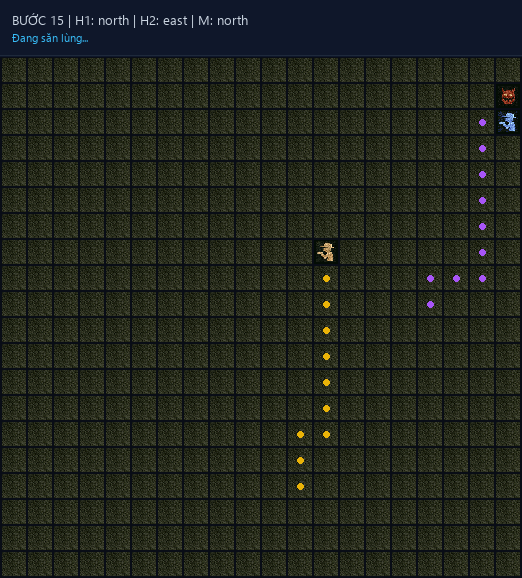
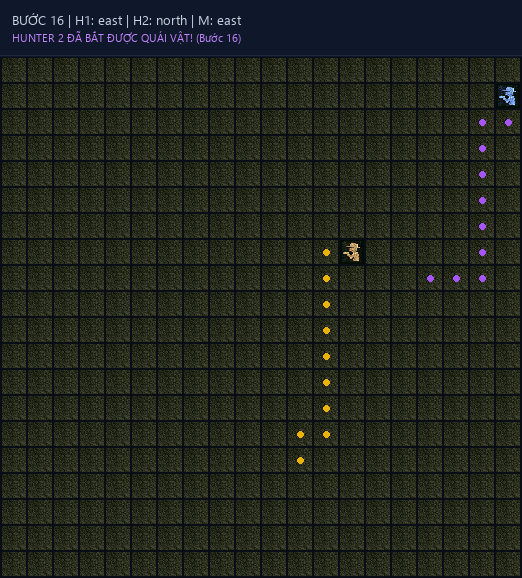

In [26]:
from gridhunt_visualizer import play_gridhunt

# Trực quan hóa 1 ván đấu giữa 2 Hunter và Smart Evasive Monster
play_gridhunt(
    hunter_1_func=smart_hunter_agent_function,
    hunter_2_func=teleport_hunter_agent_function,
    monster_func=smart_evasive_monster_agent_function,
    n=20,
    max_steps=100,
    interval=400
)